# Regression analysis overview
This notebook explores regression models for predicting COVID-19 severity using scVI latent features and participant metadata.
It evaluates XGBoost and MLP approaches on WHO severity scores, tracks model performance using regression metrics, and visualizes prediction quality.
The workflow includes dataset loading, exploratory checks, feature selection, model training, and error analysis.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('subdata/scvi_latent_75ep.csv', index_col=0)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nWHO score distribution:")
print(df['WHO_score'].value_counts().sort_index())
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")

Shape: (47495, 27)
Columns: ['scVI_1', 'scVI_2', 'scVI_3', 'scVI_4', 'scVI_5', 'scVI_6', 'scVI_7', 'scVI_8', 'scVI_9', 'scVI_10', 'scVI_11', 'scVI_12', 'scVI_13', 'scVI_14', 'scVI_15', 'scVI_16', 'scVI_17', 'scVI_18', 'scVI_19', 'scVI_20', 'cell_type', 'WHO_score', 'Participant', 'Variant_Group', 'Vaccination_Status', 'PCR_Status', 'leiden']

WHO score distribution:
WHO_score
0    10934
1     1620
2      689
3     4733
4     8251
5     4709
6     1072
7     2871
8    12616
Name: count, dtype: int64

Missing values:
0 total


I am excluding the positive controls to focus in. We are not interested in predicting if someone is healthy or sick, but in predicting how sick they'll be and why (maybe ill change it later)

In [2]:
# Check the overlap between PCR status and WHO score 0
print(pd.crosstab(df['PCR_Status'], df['WHO_score']))

WHO_score      0     1    2     3     4     5     6     7      8
PCR_Status                                                      
negative    9513     0    0     0     0     0     0     0      0
positive    1421  1620  689  4733  8251  4709  1072  2871  12616


In [3]:
# Check WHO score 0 specifically
score0 = df[df['WHO_score'] == 0]
print(f"Total WHO score 0 cells: {len(score0)}")
print(score0['PCR_Status'].value_counts())
print(score0['Variant_Group'].value_counts())

Total WHO score 0 cells: 10934
PCR_Status
negative    9513
positive    1421
Name: count, dtype: int64
Variant_Group
Control    9513
Delta      1421
Name: count, dtype: int64


# Cell level models
# Cell level model on scVI latent states
CV

Cells after filtering: 37982
WHO score distribution:
WHO_score
0     1421
1     1620
2      689
3     4733
4     8251
5     4709
6     1072
7     2871
8    12616
Name: count, dtype: int64
Fold 1: RMSE=2.134 | MAE=1.817 | R²=0.106 | train=31941 cells | test=6041 cells | test participants=13
Fold 2: RMSE=2.403 | MAE=2.136 | R²=-0.036 | train=28973 cells | test=9009 cells | test participants=14
Fold 3: RMSE=1.851 | MAE=1.507 | R²=0.140 | train=32533 cells | test=5449 cells | test participants=15
Fold 4: RMSE=2.557 | MAE=2.252 | R²=0.197 | train=26462 cells | test=11520 cells | test participants=15
Fold 5: RMSE=1.768 | MAE=1.401 | R²=-0.184 | train=32019 cells | test=5963 cells | test participants=14

CV Summary:
  RMSE: 2.142 ± 0.341
  MAE:  1.823 ± 0.374
  R²:   0.045 ± 0.154


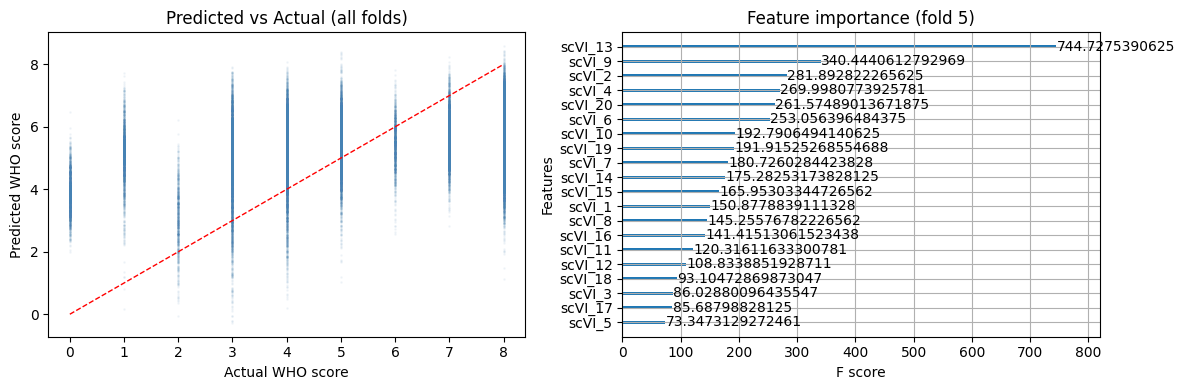

In [6]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ── Setup ─────────────────────────────────────────────────────────────────────
df_pos = df[df['PCR_Status'] == 'positive'].copy()
print(f"Cells after filtering: {len(df_pos)}")
print(f"WHO score distribution:\n{df_pos['WHO_score'].value_counts().sort_index()}")

# ── Features and target ───────────────────────────────────────────────────────
feature_cols = [f"scVI_{i+1}" for i in range(20)]
X = df_pos[feature_cols].values.astype(np.float32)
y = df_pos['WHO_score'].values.astype(np.float32)
groups = df_pos['Participant'].values

# ── Stratification bins (for balancing folds, not for prediction) ─────────────
y_binned = pd.cut(
    df_pos['WHO_score'],
    bins=[-1, 3, 5, 8],
    labels=['mild', 'moderate', 'severe']
).values

# ── 5-fold Stratified Group CV ────────────────────────────────────────────────
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=27)

fold_results = []
all_y_test  = []
all_y_pred  = []
fold_models = []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y_binned, groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Check no participant leakage
    train_parts = set(groups[train_idx])
    test_parts  = set(groups[test_idx])
    assert len(train_parts & test_parts) == 0, "Participant leakage detected!"

    model_fold = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=27,
        n_jobs=2,
        tree_method='hist'
    )

    model_fold.fit(X_train, y_train, verbose=False)
    y_pred = model_fold.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    fold_results.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2,
                         'n_train': len(y_train), 'n_test': len(y_test),
                         'test_participants': len(test_parts)})
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    fold_models.append(model_fold)

    print(f"Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f} | "
          f"train={len(y_train)} cells | test={len(y_test)} cells | "
          f"test participants={len(test_parts)}")

# ── Summary ───────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)
print(f"\nCV Summary:")
print(f"  RMSE: {results_df['rmse'].mean():.3f} ± {results_df['rmse'].std():.3f}")
print(f"  MAE:  {results_df['mae'].mean():.3f} ± {results_df['mae'].std():.3f}")
print(f"  R²:   {results_df['r2'].mean():.3f} ± {results_df['r2'].std():.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(all_y_test, all_y_pred, alpha=0.05, s=1, color='steelblue')
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=1)
axes[0].set_xlabel('Actual WHO score')
axes[0].set_ylabel('Predicted WHO score')
axes[0].set_title('Predicted vs Actual (all folds)')

# Feature importance from last fold
feature_names = [f"scVI_{i+1}" for i in range(20)]
fold_models[-1].get_booster().feature_names = feature_names
xgb.plot_importance(fold_models[-1], ax=axes[1], max_num_features=20, importance_type='gain')
axes[1].set_title('Feature importance (fold 5)')

plt.tight_layout()
plt.show()

Honest assessment:
The cell-level model with latent states alone has very weak predictive power for WHO severity (R² ≈ 0.05 on average). This makes biological sense — a single cell's gene expression is a noisy proxy for a patient-level outcome.

# Adding Cell type as feature

Cell type encoding:
  0: B_Cell
  1: Basal
  2: Ciliated
  3: Dendritic
  4: Deuterosomal
  5: Goblet
  6: Ionocytes
  7: MT-high
  8: Macrophage
  9: SARSCoV2-high
  10: Secretory
  11: Squamous
  12: T_Cell
[0]	validation_0-rmse:2.43524
[50]	validation_0-rmse:2.19478
[100]	validation_0-rmse:2.20052
[150]	validation_0-rmse:2.22105
[199]	validation_0-rmse:2.23656

With cell type — Test performance:
  RMSE: 2.237  (was 2.197)
  MAE:  1.886  (was 1.839)
  R²:   0.154  (was 0.184)


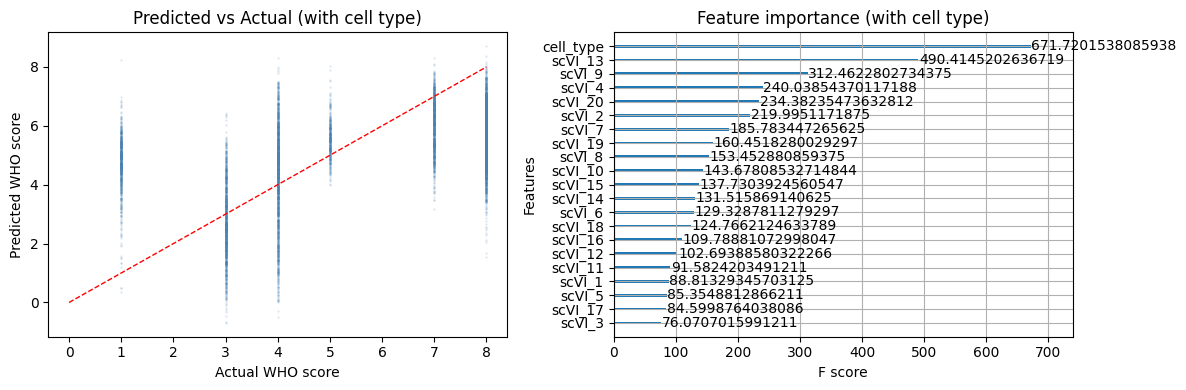

In [5]:
from sklearn.preprocessing import LabelEncoder

# ── Features with cell type ───────────────────────────────────────────────────
le = LabelEncoder()
df_pos['cell_type_encoded'] = le.fit_transform(df_pos['cell_type'])
print("Cell type encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

feature_cols_ct = [f"scVI_{i+1}" for i in range(20)] + ['cell_type_encoded']

X = df_pos[feature_cols_ct].values.astype(np.float32)
y = df_pos['WHO_score'].values.astype(np.float32)

# ── Train/test split by participant ───────────────────────────────────────────
train_mask = df_pos['Participant'].isin(train_participants).values
test_mask  = df_pos['Participant'].isin(test_participants).values

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# ── Train XGBoost ─────────────────────────────────────────────────────────────
model_ct = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=27,
    n_jobs=2,
    tree_method='hist'
)

model_ct.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_ct = model_ct.predict(X_test)

rmse_ct = np.sqrt(mean_squared_error(y_test, y_pred_ct))
mae_ct  = mean_absolute_error(y_test, y_pred_ct)
r2_ct   = r2_score(y_test, y_pred_ct)

print(f"\nWith cell type — Test performance:")
print(f"  RMSE: {rmse_ct:.3f}  (was 2.197)")
print(f"  MAE:  {mae_ct:.3f}  (was 1.839)")
print(f"  R²:   {r2_ct:.3f}  (was 0.184)")

# ── Feature importance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_ct, alpha=0.1, s=1, color='steelblue')
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=1)
axes[0].set_xlabel('Actual WHO score')
axes[0].set_ylabel('Predicted WHO score')
axes[0].set_title('Predicted vs Actual (with cell type)')

# Rename features for readability
feature_names = [f"scVI_{i+1}" for i in range(20)] + ['cell_type']
model_ct.get_booster().feature_names = feature_names
xgb.plot_importance(model_ct, ax=axes[1], max_num_features=21, importance_type='gain')
axes[1].set_title('Feature importance (with cell type)')

plt.tight_layout()
plt.show()

Adding cell type actually made the model slightly worse.

Likely explanation:
Cell type is strongly correlated with certain WHO scores in our dataset — for example, Secretory cells were massively overrepresented in severe patients (5500 severe vs 264 mild). So the model learns "Secretory = probably severe" which is a compositional effect, not a transcriptional one.It's picking up on the fact that severe patients have more of certain cell types, rather than learning what those cells are actually doing differently.
This is actually a subtle form of data leakage — cell type composition is partially a consequence of severity, so using it as a feature conflates two different things.

## With CV and StratifiedGroupKFold

Cell type encoding:
  0: B_Cell
  1: Basal
  2: Ciliated
  3: Dendritic
  4: Deuterosomal
  5: Goblet
  6: Ionocytes
  7: MT-high
  8: Macrophage
  9: SARSCoV2-high
  10: Secretory
  11: Squamous
  12: T_Cell
Fold 1: RMSE=2.116 | MAE=1.796 | R²=0.121 | train=31941 cells | test=6041 cells | test participants=13
Fold 2: RMSE=2.392 | MAE=2.125 | R²=-0.026 | train=28973 cells | test=9009 cells | test participants=14
Fold 3: RMSE=1.862 | MAE=1.525 | R²=0.130 | train=32533 cells | test=5449 cells | test participants=15
Fold 4: RMSE=2.525 | MAE=2.233 | R²=0.217 | train=26462 cells | test=11520 cells | test participants=15
Fold 5: RMSE=1.825 | MAE=1.456 | R²=-0.262 | train=32019 cells | test=5963 cells | test participants=14

CV Summary (with cell type):
  RMSE: 2.144 ± 0.312
  MAE:  1.827 ± 0.348
  R²:   0.036 ± 0.188

Comparison:
  Model                           RMSE        MAE         R²
  Latent only                    2.142      1.823      0.045
  Latent + cell type             2.144    

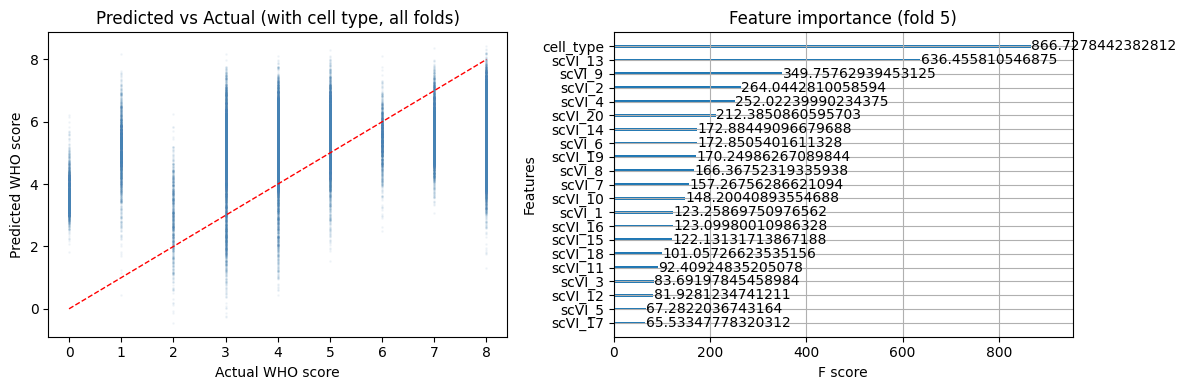

In [7]:
from sklearn.preprocessing import LabelEncoder

# ── Features with cell type ───────────────────────────────────────────────────
le = LabelEncoder()
df_pos['cell_type_encoded'] = le.fit_transform(df_pos['cell_type'])
print("Cell type encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

feature_cols_ct = [f"scVI_{i+1}" for i in range(20)] + ['cell_type_encoded']

X_ct = df_pos[feature_cols_ct].values.astype(np.float32)
y    = df_pos['WHO_score'].values.astype(np.float32)
groups = df_pos['Participant'].values

# ── Stratification bins ───────────────────────────────────────────────────────
y_binned = pd.cut(
    df_pos['WHO_score'],
    bins=[-1, 3, 5, 8],
    labels=['mild', 'moderate', 'severe']
).values

# ── 5-fold Stratified Group CV ────────────────────────────────────────────────
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=27)

fold_results_ct = []
all_y_test_ct   = []
all_y_pred_ct   = []
fold_models_ct  = []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_ct, y_binned, groups)):
    X_train, X_test = X_ct[train_idx], X_ct[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    train_parts = set(groups[train_idx])
    test_parts  = set(groups[test_idx])
    assert len(train_parts & test_parts) == 0, "Participant leakage detected!"

    model_fold_ct = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=27,
        n_jobs=2,
        tree_method='hist'
    )

    model_fold_ct.fit(X_train, y_train, verbose=False)
    y_pred = model_fold_ct.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    fold_results_ct.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2,
                            'n_train': len(y_train), 'n_test': len(y_test),
                            'test_participants': len(test_parts)})
    all_y_test_ct.extend(y_test)
    all_y_pred_ct.extend(y_pred)
    fold_models_ct.append(model_fold_ct)

    print(f"Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f} | "
          f"train={len(y_train)} cells | test={len(y_test)} cells | "
          f"test participants={len(test_parts)}")

# ── Summary ───────────────────────────────────────────────────────────────────
results_ct_df = pd.DataFrame(fold_results_ct)
print(f"\nCV Summary (with cell type):")
print(f"  RMSE: {results_ct_df['rmse'].mean():.3f} ± {results_ct_df['rmse'].std():.3f}")
print(f"  MAE:  {results_ct_df['mae'].mean():.3f} ± {results_ct_df['mae'].std():.3f}")
print(f"  R²:   {results_ct_df['r2'].mean():.3f} ± {results_ct_df['r2'].std():.3f}")

# ── Comparison ────────────────────────────────────────────────────────────────
print(f"\nComparison:")
print(f"  {'Model':<25} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print(f"  {'Latent only':<25} {results_df['rmse'].mean():>10.3f} {results_df['mae'].mean():>10.3f} {results_df['r2'].mean():>10.3f}")
print(f"  {'Latent + cell type':<25} {results_ct_df['rmse'].mean():>10.3f} {results_ct_df['mae'].mean():>10.3f} {results_ct_df['r2'].mean():>10.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
all_y_test_ct = np.array(all_y_test_ct)
all_y_pred_ct = np.array(all_y_pred_ct)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(all_y_test_ct, all_y_pred_ct, alpha=0.05, s=1, color='steelblue')
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=1)
axes[0].set_xlabel('Actual WHO score')
axes[0].set_ylabel('Predicted WHO score')
axes[0].set_title('Predicted vs Actual (with cell type, all folds)')

feature_names_ct = [f"scVI_{i+1}" for i in range(20)] + ['cell_type']
fold_models_ct[-1].get_booster().feature_names = feature_names_ct
xgb.plot_importance(fold_models_ct[-1], ax=axes[1], max_num_features=21, importance_type='gain')
axes[1].set_title('Feature importance (fold 5)')

plt.tight_layout()
plt.show()

"Cell-level XGBoost regression on scVI latent states achieves R² ≈ 0.04, with high variance across CV folds (±0.15–0.19). Adding cell type as a feature provides no improvement. This suggests that single-cell gene expression alone is a weak predictor of patient-level severity, motivating aggregation to the participant level."

# Participant level model

In [8]:
# ── Aggregate latent states to participant level ───────────────────────────────
feature_cols = [f"scVI_{i+1}" for i in range(20)]

# Aggregate: mean latent state per participant
participant_df = df_pos.groupby('Participant')[feature_cols].mean()

# Add WHO score — take the max (same for all cells from same participant)
participant_df['WHO_score'] = df_pos.groupby('Participant')['WHO_score'].first()

# Add other metadata
participant_df['Variant_Group']      = df_pos.groupby('Participant')['Variant_Group'].first()
participant_df['Vaccination_Status'] = df_pos.groupby('Participant')['Vaccination_Status'].first()

print(f"Participants: {len(participant_df)}")
print(f"\nWHO score distribution:")
print(participant_df['WHO_score'].value_counts().sort_index())
print(f"\nSample:")
print(participant_df.head(2))

Participants: 71

WHO score distribution:
WHO_score
0     1
1     4
2     1
3     9
4    17
5     8
6     3
7     5
8    23
Name: count, dtype: int64

Sample:
                scVI_1    scVI_2    scVI_3    scVI_4    scVI_5    scVI_6  \
Participant                                                                
A_COVID19_01 -0.160743 -0.102044 -0.098198  0.420918  0.203604 -1.107756   
A_COVID19_02  0.496318 -0.093439  0.541794  0.155771  0.259909 -0.129522   

               scVI_7    scVI_8    scVI_9   scVI_10  ...   scVI_14   scVI_15  \
Participant                                          ...                       
A_COVID19_01 -0.57514  0.222175 -0.101845 -0.048927  ...  0.125289  0.123884   
A_COVID19_02 -0.26411 -0.384479  0.068087  0.167508  ... -0.128909 -0.263435   

               scVI_16   scVI_17   scVI_18   scVI_19   scVI_20  WHO_score  \
Participant                                                                 
A_COVID19_01  0.198022  0.261479 -0.010784  0.184766  0.38313

very unbalanced WHO score distribution

Shape: (71, 20)
Fold 1: RMSE=2.135 | MAE=1.678 | R²=-0.257 | train=56 | test=15
Fold 2: RMSE=2.821 | MAE=2.489 | R²=-0.146 | train=57 | test=14
Fold 3: RMSE=2.900 | MAE=2.499 | R²=-0.806 | train=57 | test=14
Fold 4: RMSE=1.756 | MAE=1.547 | R²=0.295 | train=57 | test=14
Fold 5: RMSE=2.500 | MAE=2.123 | R²=-0.030 | train=57 | test=14

CV Summary (participant level):
  RMSE: 2.423 ± 0.480
  MAE:  2.067 ± 0.444
  R²:   -0.189 ± 0.402

Full Comparison:
  Model                              RMSE      MAE       R²
  Cell-level latent only            2.142    1.823    0.045
  Cell-level + cell type            2.144    1.827    0.036
  Participant-level                 2.423    2.067   -0.189


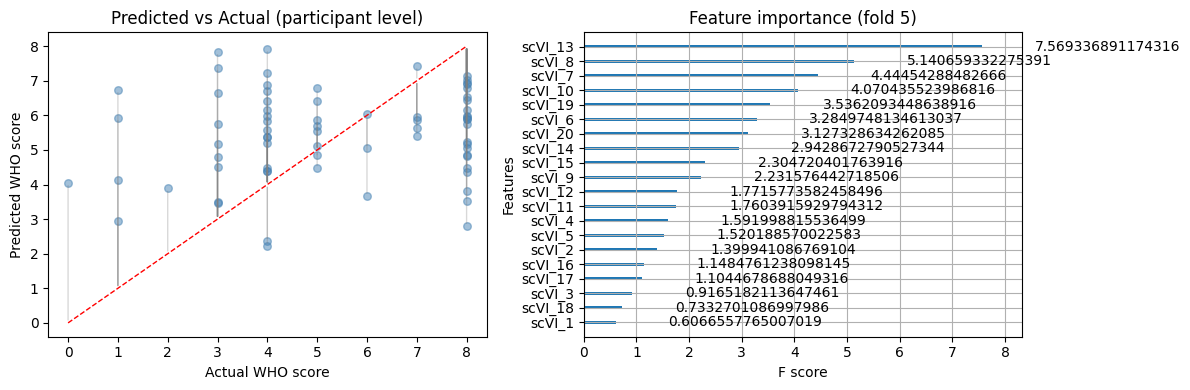

In [9]:
from sklearn.model_selection import KFold

# ── Features and target ───────────────────────────────────────────────────────
X_p = participant_df[feature_cols].values.astype(np.float32)
y_p = participant_df['WHO_score'].values.astype(np.float32)

print(f"Shape: {X_p.shape}")

# ── 5-fold CV ─────────────────────────────────────────────────────────────────
# Regular KFold is fine here — each row IS already one participant
kf = KFold(n_splits=5, shuffle=True, random_state=27)

fold_results_p = []
all_y_test_p   = []
all_y_pred_p   = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_p)):
    X_train, X_test = X_p[train_idx], X_p[test_idx]
    y_train, y_test = y_p[train_idx], y_p[test_idx]

    model_p = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=3,      # shallower — only 71 samples, less risk of overfit
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=27,
        n_jobs=2,
        tree_method='hist'
    )

    model_p.fit(X_train, y_train, verbose=False)
    y_pred = model_p.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    fold_results_p.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2,
                           'n_train': len(y_train), 'n_test': len(y_test)})
    all_y_test_p.extend(y_test)
    all_y_pred_p.extend(y_pred)

    print(f"Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f} | "
          f"train={len(y_train)} | test={len(y_test)}")

# ── Summary ───────────────────────────────────────────────────────────────────
results_p_df = pd.DataFrame(fold_results_p)
print(f"\nCV Summary (participant level):")
print(f"  RMSE: {results_p_df['rmse'].mean():.3f} ± {results_p_df['rmse'].std():.3f}")
print(f"  MAE:  {results_p_df['mae'].mean():.3f} ± {results_p_df['mae'].std():.3f}")
print(f"  R²:   {results_p_df['r2'].mean():.3f} ± {results_p_df['r2'].std():.3f}")

# ── Full comparison table ─────────────────────────────────────────────────────
print(f"\nFull Comparison:")
print(f"  {'Model':<30} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print(f"  {'Cell-level latent only':<30} {results_df['rmse'].mean():>8.3f} {results_df['mae'].mean():>8.3f} {results_df['r2'].mean():>8.3f}")
print(f"  {'Cell-level + cell type':<30} {results_ct_df['rmse'].mean():>8.3f} {results_ct_df['mae'].mean():>8.3f} {results_ct_df['r2'].mean():>8.3f}")
print(f"  {'Participant-level':<30} {results_p_df['rmse'].mean():>8.3f} {results_p_df['mae'].mean():>8.3f} {results_p_df['r2'].mean():>8.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
all_y_test_p = np.array(all_y_test_p)
all_y_pred_p = np.array(all_y_pred_p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(all_y_test_p, all_y_pred_p, alpha=0.5, s=30, color='steelblue')
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=1)
for i, (yt, yp) in enumerate(zip(all_y_test_p, all_y_pred_p)):
    axes[0].annotate('', xy=(yt, yp), xytext=(yt, yt),
                    arrowprops=dict(arrowstyle='-', color='gray', alpha=0.3))
axes[0].set_xlabel('Actual WHO score')
axes[0].set_ylabel('Predicted WHO score')
axes[0].set_title('Predicted vs Actual (participant level)')

feature_names = [f"scVI_{i+1}" for i in range(20)]
model_p.get_booster().feature_names = feature_names
xgb.plot_importance(model_p, ax=axes[1], max_num_features=20, importance_type='gain')
axes[1].set_title('Feature importance (fold 5)')

plt.tight_layout()
plt.show()

The scatter plot tells the story visually — predictions cluster around 4-6 regardless of actual score, with huge spread. The model has essentially learned to predict near the mean.
Adding controls would likely inflate performance metrics without actually improving the model's ability to predict severity among infected patients. The model would get easy wins by correctly predicting WHO=0 for healthy controls, masking poor performance on the hard part — distinguishing mild from severe infected patients.

## Trying smarter aggregation
The smarter approach is to average within each cell type separately, then concatenate. So each participant gets:

Mean latent vector for their Ciliated cells (20 values)
Mean latent vector for their Macrophages (20 values)
Mean latent vector for their T cells (20 values)
... and so on for all 13 cell types

That gives 20 × 13 = 260 features per participant, preserving cell-type-specific signals rather than blending them.

In [10]:
# ── Per-cell-type aggregation with composition features ───────────────────────

feature_cols = [f"scVI_{i+1}" for i in range(20)]
cell_types = df_pos['cell_type'].unique().tolist()
cell_types.sort()

participant_rows = []

for participant, group in df_pos.groupby('Participant'):
    row = {'Participant': participant}
    
    # WHO score and metadata
    row['WHO_score']          = group['WHO_score'].iloc[0]
    row['Variant_Group']      = group['Variant_Group'].iloc[0]
    row['Vaccination_Status'] = group['Vaccination_Status'].iloc[0]
    
    # ── Per cell type mean latent vector ──────────────────────────────────────
    for ct in cell_types:
        ct_cells = group[group['cell_type'] == ct]
        for f in feature_cols:
            if len(ct_cells) > 0:
                row[f"{ct}_{f}"] = ct_cells[f].mean()
            else:
                row[f"{ct}_{f}"] = 0.0  # participant has no cells of this type
    
    # ── Cell type proportions ─────────────────────────────────────────────────
    total_cells = len(group)
    for ct in cell_types:
        row[f"prop_{ct}"] = (group['cell_type'] == ct).sum() / total_cells
    
    participant_rows.append(row)

participant_agg_df = pd.DataFrame(participant_rows).set_index('Participant')

# ── Summary ───────────────────────────────────────────────────────────────────
latent_features = [f"{ct}_{f}" for ct in cell_types for f in feature_cols]
prop_features   = [f"prop_{ct}" for ct in cell_types]
all_features    = latent_features + prop_features

print(f"Participants:      {len(participant_agg_df)}")
print(f"Latent features:   {len(latent_features)} ({len(cell_types)} cell types × 20 dimensions)")
print(f"Prop features:     {len(prop_features)}")
print(f"Total features:    {len(all_features)}")
print(f"\nWHO score distribution:")
print(participant_agg_df['WHO_score'].value_counts().sort_index())

Participants:      71
Latent features:   260 (13 cell types × 20 dimensions)
Prop features:     13
Total features:    273

WHO score distribution:
WHO_score
0     1
1     4
2     1
3     9
4    17
5     8
6     3
7     5
8    23
Name: count, dtype: int64


Feature matrix: (71, 273)
Fold 1: RMSE=1.757 | MAE=1.438 | R²=0.149 | train=56 | test=15
Fold 2: RMSE=2.218 | MAE=1.758 | R²=0.292 | train=57 | test=14
Fold 3: RMSE=2.310 | MAE=2.032 | R²=-0.145 | train=57 | test=14
Fold 4: RMSE=1.924 | MAE=1.516 | R²=0.153 | train=57 | test=14
Fold 5: RMSE=1.957 | MAE=1.692 | R²=0.368 | train=57 | test=14

CV Summary (aggregated participant level):
  RMSE: 2.033 ± 0.226
  MAE:  1.687 ± 0.232
  R²:   0.163 ± 0.196

Full Comparison:
  Model                                        RMSE      MAE       R²
  Cell-level latent only                      2.142    1.823    0.045
  Cell-level + cell type                      2.144    1.827    0.036
  Participant mean latent                     2.423    2.067   -0.189
  Participant per-celltype + props            2.033    1.687    0.163


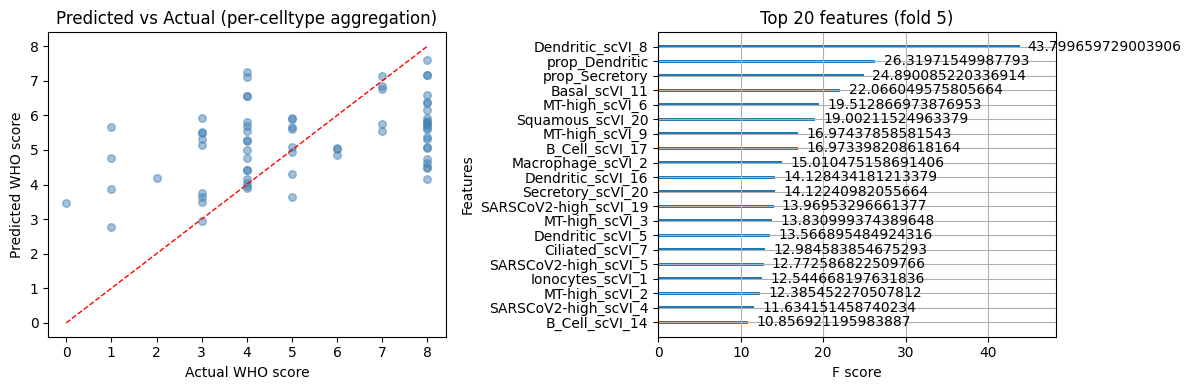

In [11]:
# ── Features and target ───────────────────────────────────────────────────────
X_agg = participant_agg_df[all_features].values.astype(np.float32)
y_agg = participant_agg_df['WHO_score'].values.astype(np.float32)

print(f"Feature matrix: {X_agg.shape}")

# ── 5-fold CV ─────────────────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=27)

fold_results_agg = []
all_y_test_agg   = []
all_y_pred_agg   = []
fold_models_agg  = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_agg)):
    X_train, X_test = X_agg[train_idx], X_agg[test_idx]
    y_train, y_test = y_agg[train_idx], y_agg[test_idx]

    model_agg = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=27,
        n_jobs=2,
        tree_method='hist'
    )

    model_agg.fit(X_train, y_train, verbose=False)
    y_pred = model_agg.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    fold_results_agg.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2,
                             'n_train': len(y_train), 'n_test': len(y_test)})
    all_y_test_agg.extend(y_test)
    all_y_pred_agg.extend(y_pred)
    fold_models_agg.append(model_agg)

    print(f"Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f} | "
          f"train={len(y_train)} | test={len(y_test)}")

# ── Summary ───────────────────────────────────────────────────────────────────
results_agg_df = pd.DataFrame(fold_results_agg)
print(f"\nCV Summary (aggregated participant level):")
print(f"  RMSE: {results_agg_df['rmse'].mean():.3f} ± {results_agg_df['rmse'].std():.3f}")
print(f"  MAE:  {results_agg_df['mae'].mean():.3f} ± {results_agg_df['mae'].std():.3f}")
print(f"  R²:   {results_agg_df['r2'].mean():.3f} ± {results_agg_df['r2'].std():.3f}")

# ── Full comparison table ─────────────────────────────────────────────────────
print(f"\nFull Comparison:")
print(f"  {'Model':<40} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print(f"  {'Cell-level latent only':<40} {results_df['rmse'].mean():>8.3f} {results_df['mae'].mean():>8.3f} {results_df['r2'].mean():>8.3f}")
print(f"  {'Cell-level + cell type':<40} {results_ct_df['rmse'].mean():>8.3f} {results_ct_df['mae'].mean():>8.3f} {results_ct_df['r2'].mean():>8.3f}")
print(f"  {'Participant mean latent':<40} {results_p_df['rmse'].mean():>8.3f} {results_p_df['mae'].mean():>8.3f} {results_p_df['r2'].mean():>8.3f}")
print(f"  {'Participant per-celltype + props':<40} {results_agg_df['rmse'].mean():>8.3f} {results_agg_df['mae'].mean():>8.3f} {results_agg_df['r2'].mean():>8.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
all_y_test_agg = np.array(all_y_test_agg)
all_y_pred_agg = np.array(all_y_pred_agg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(all_y_test_agg, all_y_pred_agg, alpha=0.5, s=30, color='steelblue')
axes[0].plot([0, 8], [0, 8], 'r--', linewidth=1)
axes[0].set_xlabel('Actual WHO score')
axes[0].set_ylabel('Predicted WHO score')
axes[0].set_title('Predicted vs Actual (per-celltype aggregation)')

# Top 20 most important features from last fold
feature_names_agg = all_features
fold_models_agg[-1].get_booster().feature_names = feature_names_agg
xgb.plot_importance(fold_models_agg[-1], ax=axes[1], max_num_features=20, importance_type='gain')
axes[1].set_title('Top 20 features (fold 5)')

plt.tight_layout()
plt.show()

"Simple mean aggregation loses biological structure and performs poorly (R²=-0.189). Preserving cell-type-specific latent representations through per-celltype aggregation, combined with cell composition features, substantially improves performance (R²=0.163), suggesting that the cell-type-resolved structure of the scVI latent space carries meaningful severity-associated information."

# Permutation test to see if it is better than random

  100/500 permutations done...
  200/500 permutations done...
  300/500 permutations done...
  400/500 permutations done...
  500/500 permutations done...

Observed R²:        0.163
Permutation R² mean: -0.304 ± 0.186
p-value:            0.000
Better than random: Yes


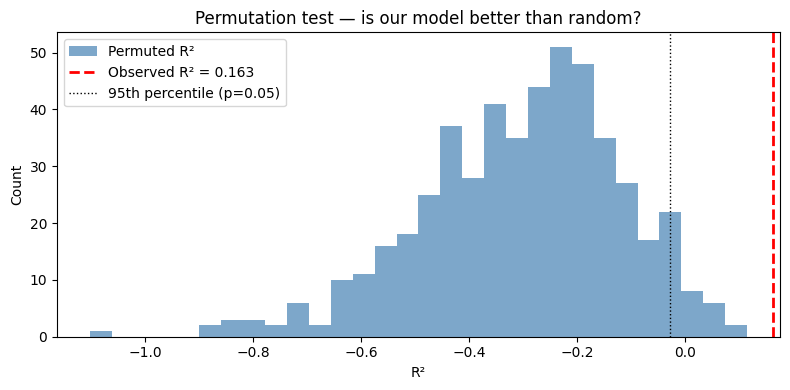

In [12]:
# ── Permutation test ──────────────────────────────────────────────────────────
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

n_permutations = 500
perm_r2_scores = []

kf_perm = KFold(n_splits=5, shuffle=True, random_state=27)

for perm in range(n_permutations):
    # Shuffle WHO scores randomly
    y_shuffled = y_agg.copy()
    np.random.shuffle(y_shuffled)
    
    fold_r2s = []
    for train_idx, test_idx in kf_perm.split(X_agg):
        X_train, X_test = X_agg[train_idx], X_agg[test_idx]
        y_train, y_test = y_shuffled[train_idx], y_shuffled[test_idx]
        
        model_perm = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.05,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.3,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=27,
            n_jobs=2,
            tree_method='hist'
        )
        model_perm.fit(X_train, y_train, verbose=False)
        y_pred = model_perm.predict(X_test)
        fold_r2s.append(r2_score(y_test, y_pred))
    
    perm_r2_scores.append(np.mean(fold_r2s))
    
    if (perm + 1) % 100 == 0:
        print(f"  {perm+1}/{n_permutations} permutations done...")

# ── Results ───────────────────────────────────────────────────────────────────
perm_r2_scores = np.array(perm_r2_scores)
observed_r2    = results_agg_df['r2'].mean()
p_value        = (perm_r2_scores >= observed_r2).mean()

print(f"\nObserved R²:        {observed_r2:.3f}")
print(f"Permutation R² mean: {perm_r2_scores.mean():.3f} ± {perm_r2_scores.std():.3f}")
print(f"p-value:            {p_value:.3f}")
print(f"Better than random: {'Yes' if p_value < 0.05 else 'No'}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_r2_scores, bins=30, color='steelblue', alpha=0.7, label='Permuted R²')
ax.axvline(observed_r2, color='red', linewidth=2, linestyle='--',
           label=f'Observed R² = {observed_r2:.3f}')
ax.axvline(np.percentile(perm_r2_scores, 95), color='black', linewidth=1,
           linestyle=':', label='95th percentile (p=0.05)')
ax.set_xlabel('R²')
ax.set_ylabel('Count')
ax.set_title('Permutation test — is our model better than random?')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# ── Permutation test summary ──────────────────────────────────────────────────
print(f"Observed R²:         {observed_r2:.3f}")
print(f"Permutation R² mean: {perm_r2_scores.mean():.3f} ± {perm_r2_scores.std():.3f}")

# Report p-value correctly as upper bound when no permutations exceed observed
if p_value == 0:
    print(f"p-value:             < {1/len(perm_r2_scores):.2e} (0 of {len(perm_r2_scores)} permutations exceeded observed R²)")
else:
    print(f"p-value:             {p_value:.2e}")

print(f"Better than random:  {'Yes' if p_value < 0.05 else 'No'}")

Observed R²:         0.163
Permutation R² mean: -0.304 ± 0.186
p-value:             < 2.00e-03 (0 of 500 permutations exceeded observed R²)
Better than random:  Yes


permutation test:
We ran 500 experiments where we randomly shuffled the WHO scores and trained the same model each time. The idea is: if our model is just getting lucky, then a model trained on randomly shuffled labels should perform just as well. But in none of the 500 random shuffles did the model achieve an R² as high as our real model (0.163).

### Conclusions
R² = 0.163 the model explains 16% of the variance in WHO severity scores

R² = 0.163 is modest. The model captures a real but weak signal. This makes biological sense for several reasons:

WHO score is a patient-level measurement being predicted from cell-level gene expression — inherently noisy
71 participants is a small dataset for this kind of prediction
Disease severity is influenced by many factors outside gene expression — age, comorbidities, immune history, genetics — none of which are in our features
The scVI latent space was trained for dimensionality reduction and batch correction, not specifically optimized for severity prediction.

Single-cell gene expression profiles, summarized as per-cell-type latent representations from scVI, contain statistically significant information about COVID-19 disease severity (R²=0.163, p<0.002). However, the modest effect size suggests that gene expression alone explains only a fraction of severity variation, consistent with the multifactorial nature of COVID-19 outcomes.


Important point:
Gene expression captures a meaningful but incomplete projection of all severity-relevant factors. R²=0.163 is probably close to the practical ceiling for this dataset and task — not because the model is bad, but because the data only partially observes the underlying biology driving severity.

In [2]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# ── Train final model on all data for SHAP ────────────────────────────────────
# We use all 71 participants rather than a single fold
final_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=27,
    n_jobs=2, tree_method='hist',
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss'
)
final_model.fit(X_m4, y_m4, verbose=False)

# ── SHAP values ───────────────────────────────────────────────────────────────
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_m4)

# shap_values is a list of 3 arrays (one per class)
# each array is shape (71, 273)
print(f"SHAP values shape per class: {shap_values[0].shape}")
print(f"Classes: 0=mild, 1=moderate, 2=severe")

# ── Feature names ─────────────────────────────────────────────────────────────
feature_names = all_agg_features

# ── Plot 1: Summary plot for severe class (most interesting) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

class_names = ['Mild', 'Moderate', 'Severe']
colors = ['#378ADD', '#1D9E75', '#E24B4A']

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    plt.figure(figsize=(8, 7))
    shap.summary_plot(
        shap_values[i],
        X_m4,
        feature_names=feature_names,
        max_display=20,
        show=False,
        plot_type='bar',
        color=color
    )
    plt.title(f'SHAP feature importance\n{cls_name} class', fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Plot 2: Beeswarm for severe class ─────────────────────────────────────────
plt.figure(figsize=(8, 7))
shap.summary_plot(
    shap_values[2],  # severe class
    X_m4,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP beeswarm — Severe class', fontsize=12)
plt.tight_layout()
plt.show()

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


NameError: name 'xgb' is not defined

# MLP
I now want to run the same 4 models on an mlp for comparison

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# ── MLP architecture ──────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

# ── Training function ─────────────────────────────────────────────────────────
def train_mlp(X_train, y_train, input_dim, hidden_dims, 
              dropout=0.3, lr=1e-3, batch_size=256, 
              max_epochs=200, patience=15, device='cpu'):
    
    # Carve out 15% of training data for early stopping
    n_val = max(1, int(0.15 * len(X_train)))
    idx   = np.random.permutation(len(X_train))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    X_tr = torch.tensor(X_train[tr_idx],  dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train[tr_idx],  dtype=torch.float32).to(device)
    X_vl = torch.tensor(X_train[val_idx], dtype=torch.float32).to(device)
    y_vl = torch.tensor(y_train[val_idx], dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr, y_tr), 
                        batch_size=batch_size, shuffle=True)

    model = MLP(input_dim, hidden_dims, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_weights  = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl), y_vl).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_weights)
    return model

# ── Prediction function ───────────────────────────────────────────────────────
def predict_mlp(model, X, device='cpu'):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        return model(X_t).cpu().numpy()

# ── CV function (reusable for all 4 models) ───────────────────────────────────
def run_mlp_cv(X, y, groups, cv, hidden_dims, 
               dropout=0.3, lr=1e-3, batch_size=256,
               max_epochs=200, patience=15,
               stratify=None, model_name='MLP', device='cpu'):
    
    scaler = StandardScaler()
    fold_results = []
    all_y_test   = []
    all_y_pred   = []

    split_args = (X, stratify, groups) if stratify is not None else (X,)
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(*split_args)):
        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train_f,   y_test_f   = y[train_idx], y[test_idx]

        # Scale features
        X_train_s = scaler.fit_transform(X_train_raw).astype(np.float32)
        X_test_s  = scaler.transform(X_test_raw).astype(np.float32)

        model_fold = train_mlp(
            X_train_s, y_train_f,
            input_dim=X.shape[1],
            hidden_dims=hidden_dims,
            dropout=dropout, lr=lr,
            batch_size=batch_size,
            max_epochs=max_epochs,
            patience=patience,
            device=device
        )

        y_pred = predict_mlp(model_fold, X_test_s, device)

        rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))
        mae  = mean_absolute_error(y_test_f, y_pred)
        r2   = r2_score(y_test_f, y_pred)

        fold_results.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2})
        all_y_test.extend(y_test_f)
        all_y_pred.extend(y_pred)

        print(f"  Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f}")

    results_df = pd.DataFrame(fold_results)
    print(f"\n  CV Summary ({model_name}):")
    print(f"    RMSE: {results_df['rmse'].mean():.3f} ± {results_df['rmse'].std():.3f}")
    print(f"    MAE:  {results_df['mae'].mean():.3f} ± {results_df['mae'].std():.3f}")
    print(f"    R²:   {results_df['r2'].mean():.3f} ± {results_df['r2'].std():.3f}")

    return results_df, np.array(all_y_test), np.array(all_y_pred)

# ── Device ────────────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [19]:
# ── Model 1: Cell-level latent only ──────────────────────────────────────────
print("=" * 60)
print("Model 1: Cell-level latent only")
X_m1 = df_pos[[f"scVI_{i+1}" for i in range(20)]].values.astype(np.float32)
y_m1 = df_pos['WHO_score'].values.astype(np.float32)
groups_m1 = df_pos['Participant'].values
y_binned_m1 = pd.cut(df_pos['WHO_score'], bins=[-1,3,5,8],
                     labels=['mild','moderate','severe']).values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=27)
res_mlp1, yt1, yp1 = run_mlp_cv(
    X_m1, y_m1, groups_m1, sgkf,
    hidden_dims=[64, 32],
    stratify=y_binned_m1,
    model_name='Cell latent only',
    device=device
)

# ── Model 2: Cell-level latent + cell type ────────────────────────────────────
print("\n" + "=" * 60)
print("Model 2: Cell-level latent + cell type")
X_m2 = df_pos[[f"scVI_{i+1}" for i in range(20)] + ['cell_type_encoded']].values.astype(np.float32)
y_m2 = y_m1
res_mlp2, yt2, yp2 = run_mlp_cv(
    X_m2, y_m2, groups_m1, sgkf,
    hidden_dims=[64, 32],
    stratify=y_binned_m1,
    model_name='Cell latent + cell type',
    device=device
)

# ── Model 3: Participant mean latent ──────────────────────────────────────────
print("\n" + "=" * 60)
print("Model 3: Participant mean latent")
X_m3 = participant_df[feature_cols].values.astype(np.float32)
y_m3 = participant_df['WHO_score'].values.astype(np.float32)

kf = KFold(n_splits=5, shuffle=True, random_state=27)
res_mlp3, yt3, yp3 = run_mlp_cv(
    X_m3, y_m3, None, kf,
    hidden_dims=[32, 16],
    batch_size=16,
    model_name='Participant mean latent',
    device=device
)

# ── Model 4: Participant per-celltype + composition ───────────────────────────
print("\n" + "=" * 60)
print("Model 4: Participant per-celltype + composition")
X_m4 = participant_agg_df[all_features].values.astype(np.float32)
y_m4 = participant_agg_df['WHO_score'].values.astype(np.float32)

res_mlp4, yt4, yp4 = run_mlp_cv(
    X_m4, y_m4, None, kf,
    hidden_dims=[128, 64],
    dropout=0.4,
    batch_size=16,
    model_name='Participant per-celltype + props',
    device=device
)

# ── Full comparison ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FULL COMPARISON — XGBoost vs MLP")
print(f"\n{'Model':<35} {'XGB R²':>8} {'MLP R²':>8}")
print(f"{'Cell latent only':<35} {results_df['r2'].mean():>8.3f} {res_mlp1['r2'].mean():>8.3f}")
print(f"{'Cell latent + cell type':<35} {results_ct_df['r2'].mean():>8.3f} {res_mlp2['r2'].mean():>8.3f}")
print(f"{'Participant mean latent':<35} {results_p_df['r2'].mean():>8.3f} {res_mlp3['r2'].mean():>8.3f}")
print(f"{'Participant per-celltype + props':<35} {results_agg_df['r2'].mean():>8.3f} {res_mlp4['r2'].mean():>8.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (yt, yp, title) in enumerate([
    (yt1, yp1, 'Cell latent only'),
    (yt2, yp2, 'Cell latent + cell type'),
    (yt3, yp3, 'Participant mean'),
    (yt4, yp4, 'Participant per-celltype')
]):
    # MLP row
    axes[0, i].scatter(yt, yp, alpha=0.05, s=1, color='steelblue')
    axes[0, i].plot([0, 8], [0, 8], 'r--', linewidth=1)
    axes[0, i].set_title(f'MLP: {title}')
    axes[0, i].set_xlabel('Actual')
    axes[0, i].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

Model 1: Cell-level latent only
  Fold 1: RMSE=2.234 | MAE=1.830 | R²=0.020
  Fold 2: RMSE=2.482 | MAE=2.177 | R²=-0.105
  Fold 3: RMSE=1.957 | MAE=1.614 | R²=0.039
  Fold 4: RMSE=2.659 | MAE=2.341 | R²=0.131
  Fold 5: RMSE=1.709 | MAE=1.355 | R²=-0.107

  CV Summary (Cell latent only):
    RMSE: 2.208 ± 0.384
    MAE:  1.863 ± 0.403
    R²:   -0.004 ± 0.102

Model 2: Cell-level latent + cell type
  Fold 1: RMSE=2.194 | MAE=1.807 | R²=0.054
  Fold 2: RMSE=2.486 | MAE=2.174 | R²=-0.108
  Fold 3: RMSE=1.961 | MAE=1.619 | R²=0.035
  Fold 4: RMSE=2.583 | MAE=2.285 | R²=0.180
  Fold 5: RMSE=1.735 | MAE=1.399 | R²=-0.140

  CV Summary (Cell latent + cell type):
    RMSE: 2.192 ± 0.354
    MAE:  1.857 ± 0.372
    R²:   0.004 ± 0.130

Model 3: Participant mean latent
  Fold 1: RMSE=2.233 | MAE=1.765 | R²=-0.375


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 32])

Crash... moving on with model 3 and 4:

In [20]:
# ── Fixed MLP architecture without BatchNorm (for small datasets) ─────────────
class MLPSmall(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

# ── Model 3: Participant mean latent ──────────────────────────────────────────
print("=" * 60)
print("Model 3: Participant mean latent")
X_m3 = participant_df[feature_cols].values.astype(np.float32)
y_m3 = participant_df['WHO_score'].values.astype(np.float32)

kf = KFold(n_splits=5, shuffle=True, random_state=27)

fold_results_m3 = []
all_y_test_m3   = []
all_y_pred_m3   = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_m3)):
    X_train_raw, X_test_raw = X_m3[train_idx], X_m3[test_idx]
    y_train_f,   y_test_f   = y_m3[train_idx], y_m3[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_test_s  = scaler.transform(X_test_raw).astype(np.float32)

    # Use MLPSmall without BatchNorm
    model_fold = MLPSmall(input_dim=X_m3.shape[1], hidden_dims=[32, 16], dropout=0.3).to(device)
    optimizer  = torch.optim.Adam(model_fold.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion  = nn.MSELoss()

    X_tr = torch.tensor(X_train_s, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train_f, dtype=torch.float32).to(device)

    # Simple training without early stopping inner split (too few samples)
    model_fold.train()
    for epoch in range(200):
        optimizer.zero_grad()
        loss = criterion(model_fold(X_tr), y_tr)
        loss.backward()
        optimizer.step()

    y_pred = predict_mlp(model_fold, X_test_s, device)

    rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))
    mae  = mean_absolute_error(y_test_f, y_pred)
    r2   = r2_score(y_test_f, y_pred)

    fold_results_m3.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2})
    all_y_test_m3.extend(y_test_f)
    all_y_pred_m3.extend(y_pred)
    print(f"  Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f}")

res_mlp3 = pd.DataFrame(fold_results_m3)
print(f"\n  CV Summary (Participant mean latent):")
print(f"    RMSE: {res_mlp3['rmse'].mean():.3f} ± {res_mlp3['rmse'].std():.3f}")
print(f"    MAE:  {res_mlp3['mae'].mean():.3f} ± {res_mlp3['mae'].std():.3f}")
print(f"    R²:   {res_mlp3['r2'].mean():.3f} ± {res_mlp3['r2'].std():.3f}")

# ── Model 4: Participant per-celltype + composition ───────────────────────────
print("\n" + "=" * 60)
print("Model 4: Participant per-celltype + composition")
X_m4 = participant_agg_df[all_features].values.astype(np.float32)
y_m4 = participant_agg_df['WHO_score'].values.astype(np.float32)

fold_results_m4 = []
all_y_test_m4   = []
all_y_pred_m4   = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_m4)):
    X_train_raw, X_test_raw = X_m4[train_idx], X_m4[test_idx]
    y_train_f,   y_test_f   = y_m4[train_idx], y_m4[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_test_s  = scaler.transform(X_test_raw).astype(np.float32)

    model_fold = MLPSmall(input_dim=X_m4.shape[1], hidden_dims=[128, 64], dropout=0.4).to(device)
    optimizer  = torch.optim.Adam(model_fold.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion  = nn.MSELoss()

    X_tr = torch.tensor(X_train_s, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train_f, dtype=torch.float32).to(device)

    model_fold.train()
    for epoch in range(200):
        optimizer.zero_grad()
        loss = criterion(model_fold(X_tr), y_tr)
        loss.backward()
        optimizer.step()

    y_pred = predict_mlp(model_fold, X_test_s, device)

    rmse = np.sqrt(mean_squared_error(y_test_f, y_pred))
    mae  = mean_absolute_error(y_test_f, y_pred)
    r2   = r2_score(y_test_f, y_pred)

    fold_results_m4.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'r2': r2})
    all_y_test_m4.extend(y_test_f)
    all_y_pred_m4.extend(y_pred)
    print(f"  Fold {fold+1}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f}")

res_mlp4 = pd.DataFrame(fold_results_m4)
print(f"\n  CV Summary (Participant per-celltype + props):")
print(f"    RMSE: {res_mlp4['rmse'].mean():.3f} ± {res_mlp4['rmse'].std():.3f}")
print(f"    MAE:  {res_mlp4['mae'].mean():.3f} ± {res_mlp4['mae'].std():.3f}")
print(f"    R²:   {res_mlp4['r2'].mean():.3f} ± {res_mlp4['r2'].std():.3f}")

# ── Full comparison ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FULL COMPARISON — XGBoost vs MLP")
print(f"\n{'Model':<35} {'XGB RMSE':>10} {'XGB R²':>8} {'MLP RMSE':>10} {'MLP R²':>8}")
print(f"{'Cell latent only':<35} {results_df['rmse'].mean():>10.3f} {results_df['r2'].mean():>8.3f} {res_mlp1['rmse'].mean():>10.3f} {res_mlp1['r2'].mean():>8.3f}")
print(f"{'Cell latent + cell type':<35} {results_ct_df['rmse'].mean():>10.3f} {results_ct_df['r2'].mean():>8.3f} {res_mlp2['rmse'].mean():>10.3f} {res_mlp2['r2'].mean():>8.3f}")
print(f"{'Participant mean latent':<35} {results_p_df['rmse'].mean():>10.3f} {results_p_df['r2'].mean():>8.3f} {res_mlp3['rmse'].mean():>10.3f} {res_mlp3['r2'].mean():>8.3f}")
print(f"{'Participant per-celltype + props':<35} {results_agg_df['rmse'].mean():>10.3f} {results_agg_df['r2'].mean():>8.3f} {res_mlp4['rmse'].mean():>10.3f} {res_mlp4['r2'].mean():>8.3f}")

Model 3: Participant mean latent
  Fold 1: RMSE=2.562 | MAE=1.837 | R²=-0.810
  Fold 2: RMSE=2.680 | MAE=2.237 | R²=-0.035
  Fold 3: RMSE=3.005 | MAE=2.155 | R²=-0.939
  Fold 4: RMSE=2.785 | MAE=2.175 | R²=-0.774
  Fold 5: RMSE=2.360 | MAE=1.963 | R²=0.082

  CV Summary (Participant mean latent):
    RMSE: 2.679 ± 0.241
    MAE:  2.073 ± 0.167
    R²:   -0.495 ± 0.479

Model 4: Participant per-celltype + composition
  Fold 1: RMSE=1.632 | MAE=1.296 | R²=0.265
  Fold 2: RMSE=2.782 | MAE=2.200 | R²=-0.115
  Fold 3: RMSE=2.698 | MAE=2.255 | R²=-0.563
  Fold 4: RMSE=2.705 | MAE=2.304 | R²=-0.673
  Fold 5: RMSE=2.067 | MAE=1.636 | R²=0.296

  CV Summary (Participant per-celltype + props):
    RMSE: 2.377 ± 0.506
    MAE:  1.938 ± 0.449
    R²:   -0.158 ± 0.452

FULL COMPARISON — XGBoost vs MLP

Model                                 XGB RMSE   XGB R²   MLP RMSE   MLP R²
Cell latent only                         2.142    0.045      2.208   -0.004
Cell latent + cell type                  2.144 

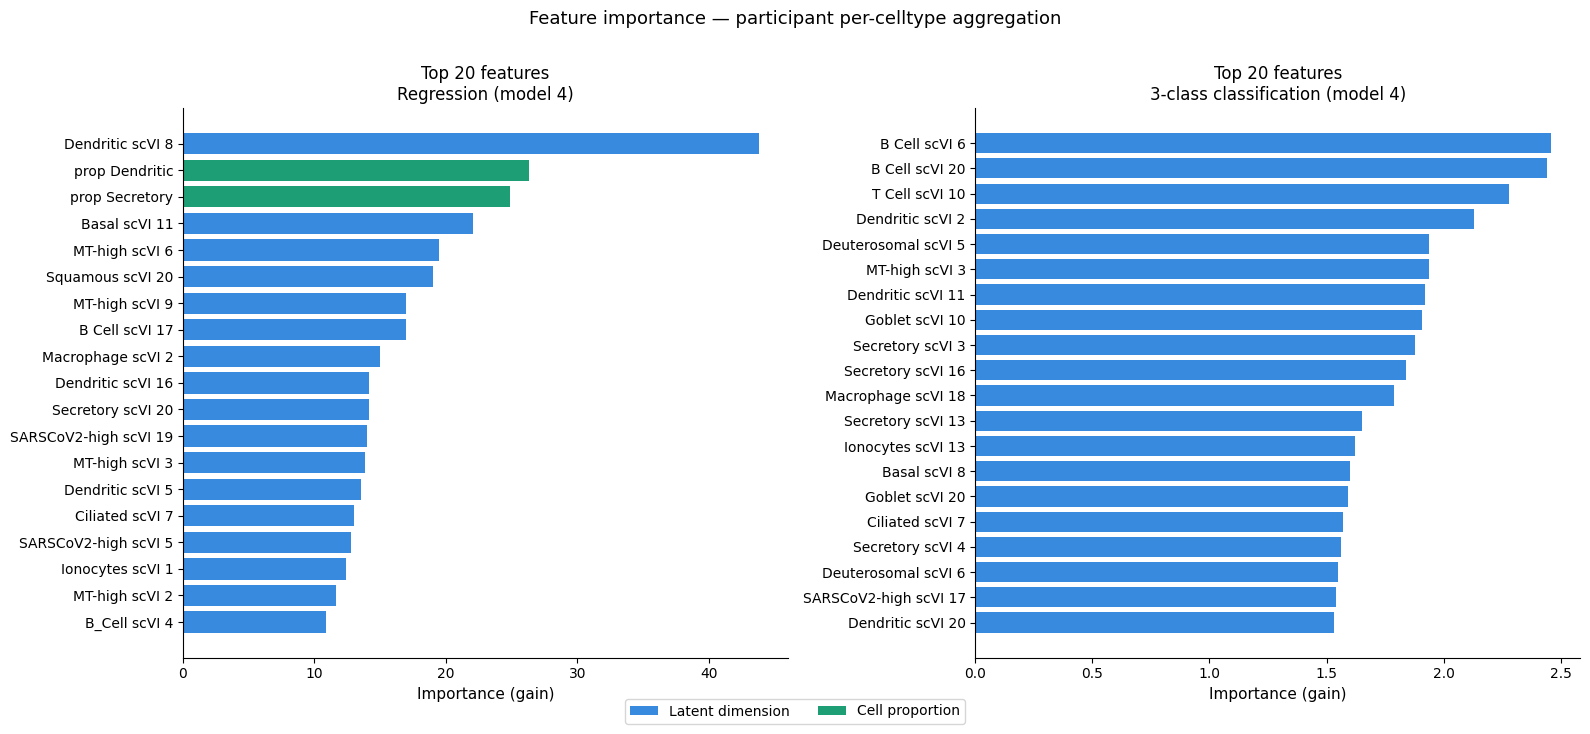

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ──────────────────────────────────────────────────────────────────────
# Regression top 20
reg_features = [
    'B_Cell scVI 4', 'MT-high scVI 2', 'Ionocytes scVI 1', 'SARSCoV2-high scVI 5',
    'Ciliated scVI 7', 'Dendritic scVI 5', 'MT-high scVI 3', 'SARSCoV2-high scVI 19',
    'Secretory scVI 20', 'Dendritic scVI 16', 'Macrophage scVI 2', 'B Cell scVI 17',
    'MT-high scVI 9', 'Squamous scVI 20', 'MT-high scVI 6', 'Basal scVI 11',
    'prop Secretory', 'prop Dendritic', 'Dendritic scVI 8'
]
reg_values = [
    10.86, 11.63, 12.39, 12.77, 12.98, 13.57, 13.83, 13.97,
    14.12, 14.13, 15.01, 16.97, 16.97, 19.00, 19.51, 22.07,
    24.89, 26.32, 43.80
]
reg_colors = ['#1D9E75' if 'prop' in f else '#378ADD' for f in reg_features]

# Classification top 20
cls_features = [
    'Dendritic scVI 20', 'SARSCoV2-high scVI 17', 'Deuterosomal scVI 6',
    'Secretory scVI 4', 'Ciliated scVI 7', 'Goblet scVI 20',
    'Basal scVI 8', 'Ionocytes scVI 13', 'Secretory scVI 13',
    'Macrophage scVI 18', 'Secretory scVI 16', 'Secretory scVI 3',
    'Goblet scVI 10', 'Dendritic scVI 11', 'MT-high scVI 3',
    'Deuterosomal scVI 5', 'Dendritic scVI 2', 'T Cell scVI 10',
    'B Cell scVI 20', 'B Cell scVI 6'
]
cls_values = [
    1.53, 1.54, 1.55, 1.56, 1.57, 1.59, 1.60, 1.62, 1.65,
    1.79, 1.84, 1.88, 1.91, 1.92, 1.94, 1.94, 2.13, 2.28, 2.44, 2.46
]
cls_colors = ['#1D9E75' if 'prop' in f else '#378ADD' for f in cls_features]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, features, values, colors, title in [
    (axes[0], reg_features, reg_values, reg_colors,
     'Top 20 features\nRegression (model 4)'),
    (axes[1], cls_features, cls_values, cls_colors,
     'Top 20 features\n3-class classification (model 4)')
]:
    ax.barh(features, values, color=colors)
    ax.set_xlabel('Importance (gain)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)

# Shared legend
legend_elements = [
    mpatches.Patch(facecolor='#378ADD', label='Latent dimension'),
    mpatches.Patch(facecolor='#1D9E75', label='Cell proportion')
]
fig.legend(handles=legend_elements, fontsize=10,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Feature importance — participant per-celltype aggregation',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()